# Maximum Likelihood and MAP

**Goal.** Derive and verify the Gaussian mean MLE, then show shrinkage from a Gaussian prior.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)


## HOW

For $x_i\sim\mathcal{N}(\mu,\sigma^2)$ with known $\sigma^2$, differentiating the log-likelihood gives $\hat{\mu}_{\mathrm{MLE}}=\bar{x}$. With prior $\mu\sim\mathcal{N}(0,\tau^2)$, MAP shrinks the sample mean toward zero.


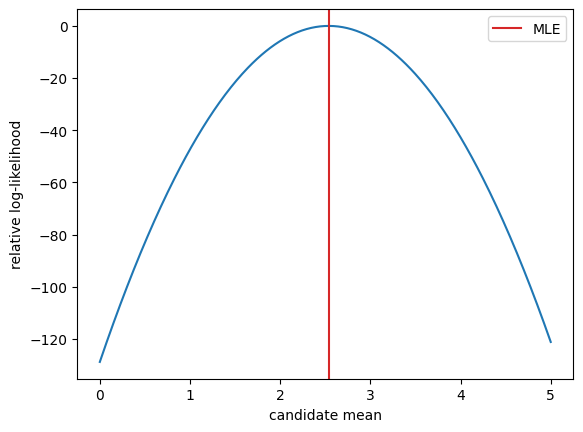

In [2]:
data = rng.normal(loc=2.5, scale=1.0, size=40)
grid = np.linspace(0.0, 5.0, 400)
log_likelihood = -0.5 * np.sum((data[:, None]-grid[None, :])**2, axis=0)
mle_grid = grid[np.argmax(log_likelihood)]
mle_closed = data.mean()
assert np.isclose(mle_grid, mle_closed, atol=0.02)

sigma2 = 1.0
tau2 = 0.25
map_mean = (len(data)*mle_closed/sigma2) / (len(data)/sigma2 + 1.0/tau2)
assert abs(map_mean) < abs(mle_closed)
plt.plot(grid, log_likelihood-log_likelihood.max())
plt.axvline(mle_closed, color="tab:red", label="MLE")
plt.xlabel("candidate mean")
plt.ylabel("relative log-likelihood")
plt.legend()
plt.show()


## CONNECTIONS

Likelihood produces loss functions; priors produce regularizers. See the [probabilistic synthesis](../../synthesis/probabilistic_view_of_ml.md).
